In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# Load data and clean it up

In [59]:
# Load the data
df = pd.read_csv("data/training_set_VU_DM.csv")

df = df[(df["price_usd"] >= 10) & (df["price_usd"] <= 1000)]

Mean ratio: 7.832158445380067
Median ratio: 3.32672131147541
Example ratios:
count     70309.000000
mean          7.832158
std         810.861381
min           0.000326
25%           2.297953
50%           3.326721
75%           4.635182
max      213334.000000
Name: gross_to_price_ratio, dtype: float64


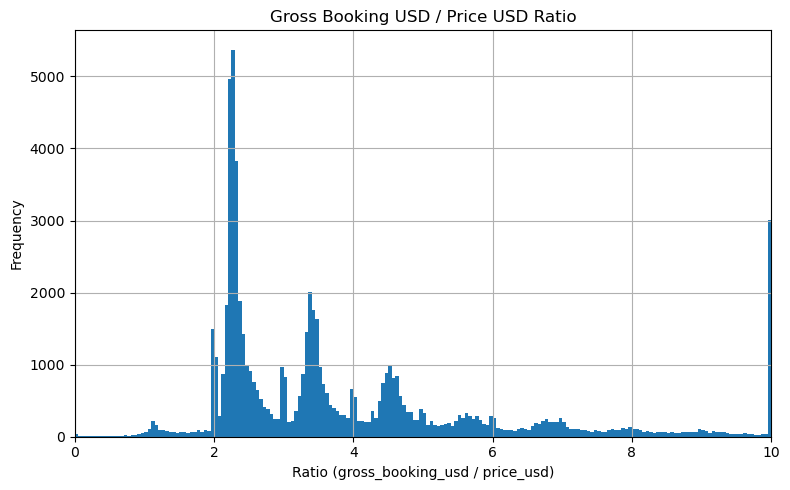

In [ ]:



# Keep only rows where both values are available
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]

# remove 1-night stays
df = df[df["srch_length_of_stay"] != 1]

# Calculate the ratio
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]

# Summary stats
print("Mean ratio:", df["gross_to_price_ratio"].mean())
print("Median ratio:", df["gross_to_price_ratio"].median())
print("Example ratios:")
print(df["gross_to_price_ratio"].describe())

# Plot
plt.figure(figsize=(8, 5))
df["gross_to_price_ratio"].clip(upper=10).hist(bins=200)
plt.title("Gross Booking USD / Price USD Ratio")
plt.xlabel("Ratio (gross_booking_usd / price_usd)")
plt.ylabel("Frequency")
plt.xlim(0, 10)  # Set x-axis limit
plt.grid(True)
plt.tight_layout()
plt.show()


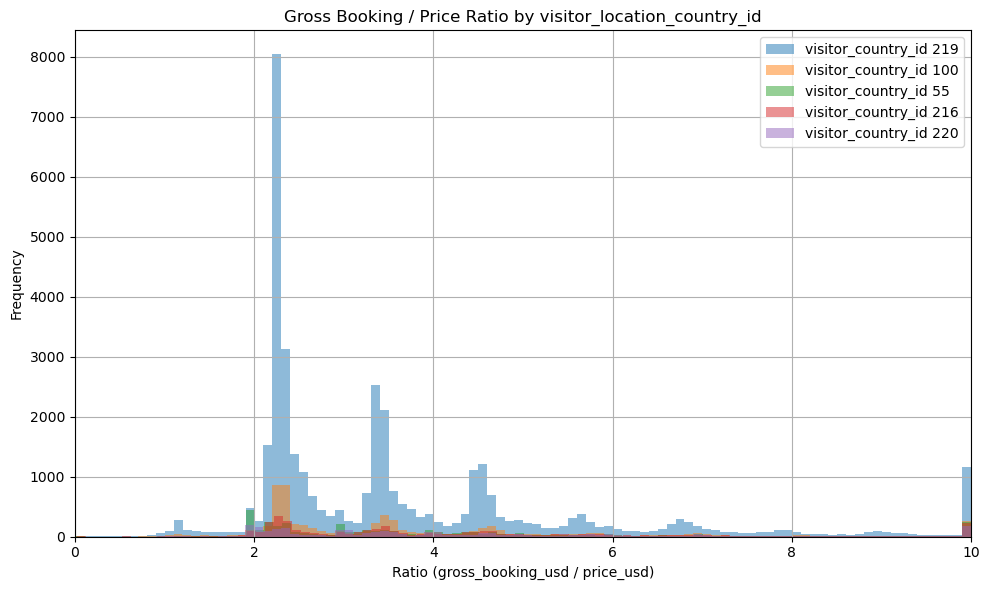

Visitor country IDs where ALL ratios are <= 2: [112, 226]


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]

# Remove 1-night stays
df = df[df["srch_length_of_stay"] != 1]

# Compute ratio
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]

# Limit to top 5 visitor_location_country_id for plotting
visitor_ids = df["visitor_location_country_id"].value_counts().head(5).index.tolist()

# Clip outliers for plotting
df["ratio_clipped"] = df["gross_to_price_ratio"].clip(upper=10)

# Plot
plt.figure(figsize=(10, 6))
for visitor_id in visitor_ids:
    subset = df[df["visitor_location_country_id"] == visitor_id]
    plt.hist(subset["ratio_clipped"], bins=100, alpha=0.5, label=f"visitor_country_id {visitor_id}")

plt.title("Gross Booking / Price Ratio by visitor_location_country_id")
plt.xlabel("Ratio (gross_booking_usd / price_usd)")
plt.ylabel("Frequency")
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ Identify visitor_location_country_ids where ALL ratios are <= 2
visitors_all_under_threshold = (
    df.groupby("visitor_location_country_id")["gross_to_price_ratio"].max()
    .loc[lambda x: x <= 2]
    .index
    .tolist()
)

print("Visitor country IDs where ALL ratios are <= 2:", visitors_all_under_threshold)



/var/folders/wr/9y41gxms3jngx9f5sf94hxkc0000gn/T/ipykernel_8863/2758513819.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["ratio_clipped"] = subset["gross_to_price_ratio"].clip(upper=10)


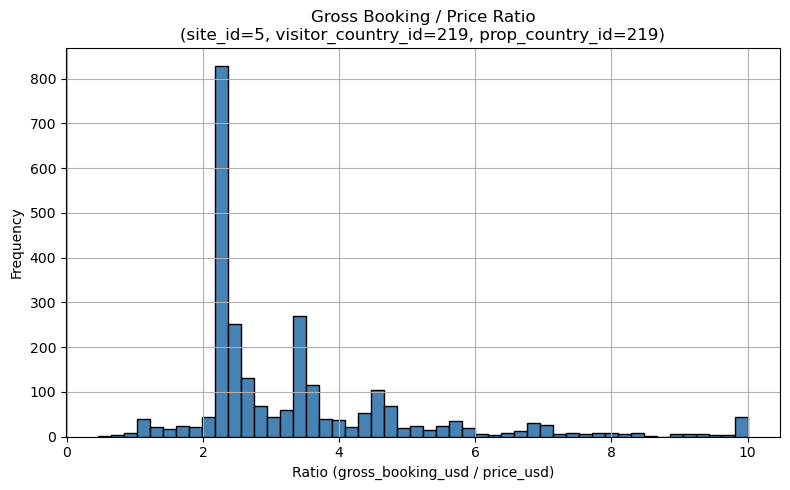

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]
df = df[df["srch_length_of_stay"] != 1]
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]

# Filter for the specific combination
subset = df[
    (df["site_id"] == 14) &
    (df["visitor_location_country_id"] == 100) &
    (df["prop_country_id"] == 100)
]

# Clip for better visibility in plot
subset["ratio_clipped"] = subset["gross_to_price_ratio"].clip(upper=10)

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(subset["ratio_clipped"], bins=50, color='steelblue', edgecolor='black')
plt.title("Gross Booking / Price Ratio\n(site_id=5, visitor_country_id=219, prop_country_id=219)")
plt.xlabel("Ratio (gross_booking_usd / price_usd)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


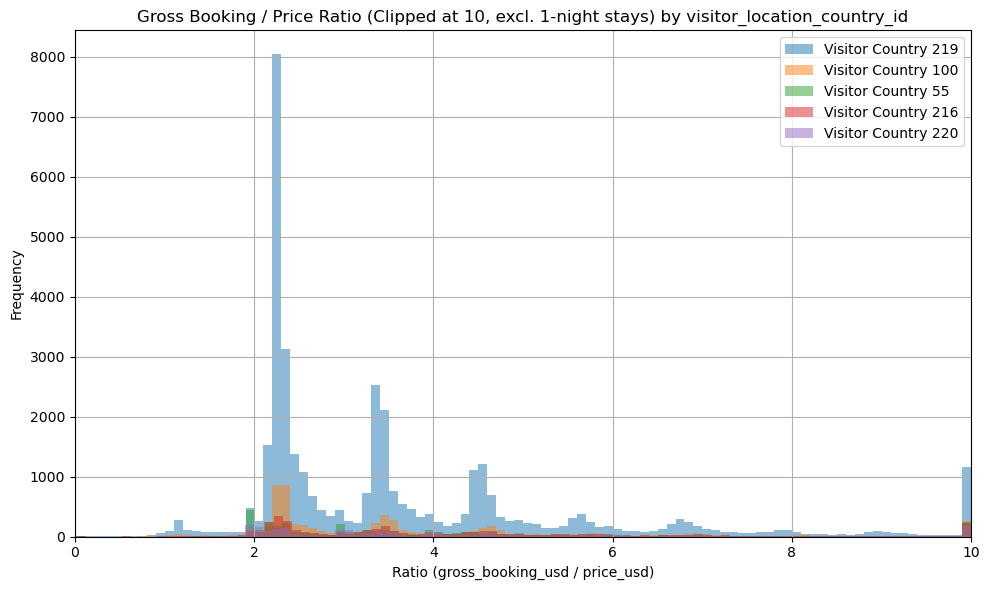

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]

# Remove 1-night stays
df = df[df["srch_length_of_stay"] != 1]

# Compute ratio
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]
df["ratio_clipped"] = df["gross_to_price_ratio"].clip(upper=10)

# Top 5 visitor countries
top_visitors = df["visitor_location_country_id"].value_counts().nlargest(5).index

# Plot
plt.figure(figsize=(10, 6))
for country in top_visitors:
    subset = df[df["visitor_location_country_id"] == country]
    plt.hist(subset["ratio_clipped"], bins=100, alpha=0.5, label=f"Visitor Country {country}")

plt.title("Gross Booking / Price Ratio (Clipped at 10, excl. 1-night stays) by visitor_location_country_id")
plt.xlabel("Ratio (gross_booking_usd / price_usd)")
plt.ylabel("Frequency")
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


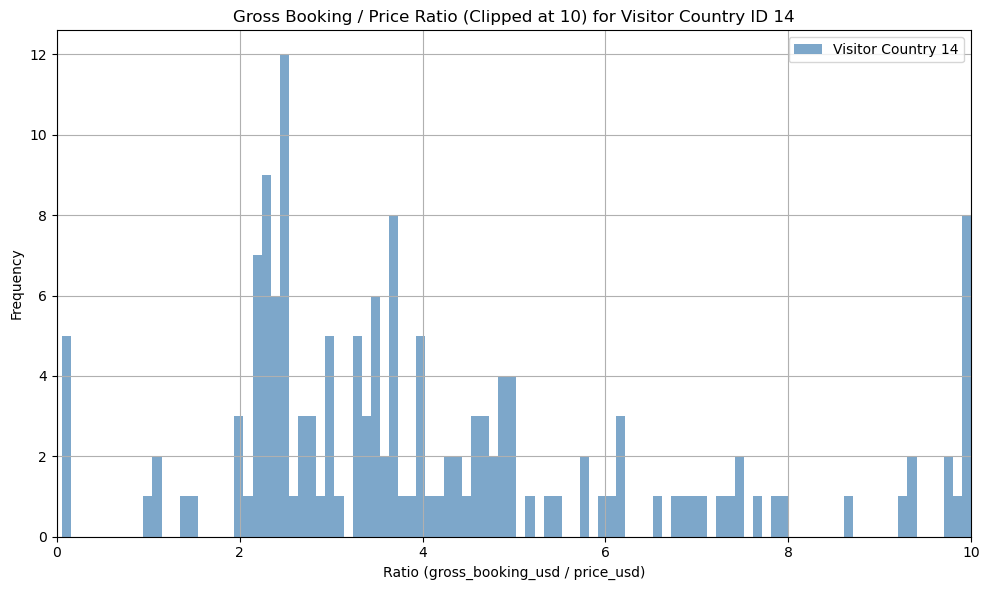

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]

# Remove 1-night stays
df = df[df["srch_length_of_stay"] != 1]

# Compute ratio
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]
df["ratio_clipped"] = df["gross_to_price_ratio"].clip(upper=10)

# Subset for visitor_location_country_id == 14
subset = df[df["visitor_location_country_id"] == 14]

# Plot
plt.figure(figsize=(10, 6))
plt.hist(subset["ratio_clipped"], bins=100, alpha=0.7, color="steelblue", label="Visitor Country 14")

plt.title("Gross Booking / Price Ratio (Clipped at 10) for Visitor Country ID 14")
plt.xlabel("Ratio (gross_booking_usd / price_usd)")
plt.ylabel("Frequency")
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


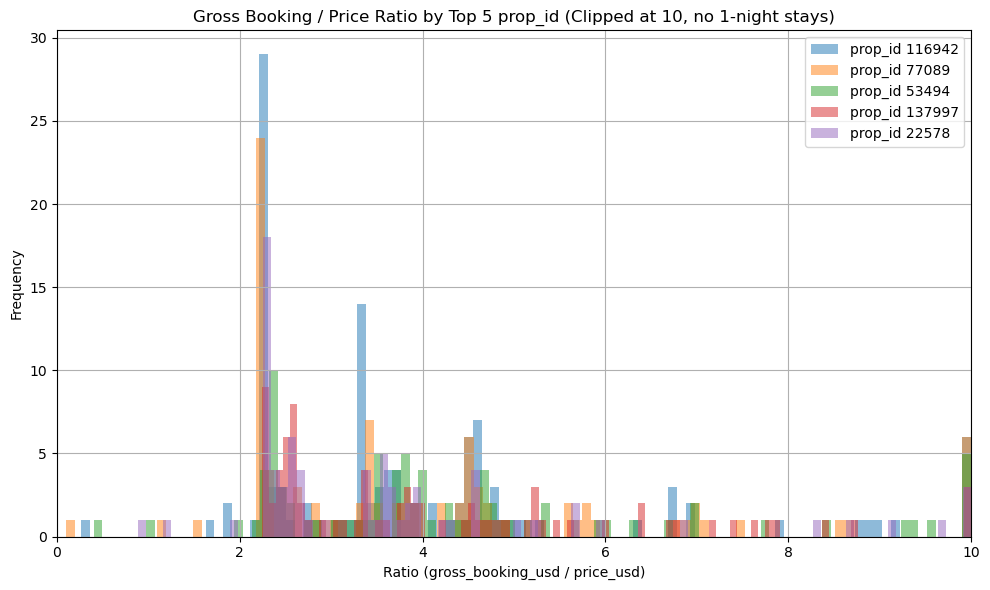

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]
df = df[df["srch_length_of_stay"] != 1]

# Compute ratio and clip
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]
df["ratio_clipped"] = df["gross_to_price_ratio"].clip(upper=10)

# Top 5 most frequent prop_ids
top_props = df["prop_id"].value_counts().nlargest(5).index

# Plot
plt.figure(figsize=(10, 6))
for prop in top_props:
    subset = df[df["prop_id"] == prop]
    plt.hist(subset["ratio_clipped"], bins=100, alpha=0.5, label=f"prop_id {prop}")

plt.title("Gross Booking / Price Ratio by Top 5 prop_id (Clipped at 10, no 1-night stays)")
plt.xlabel("Ratio (gross_booking_usd / price_usd)")
plt.ylabel("Frequency")
plt.xlim(0, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
import pandas as pd

# Load and preprocess
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]
df = df[df["srch_length_of_stay"] != 1]
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]

# Group by prop_id and compute stats including max
prop_ratios = df.groupby("prop_id")["gross_to_price_ratio"].agg(["count", "mean", "median", "max"]).reset_index()

# Label only those properties where ALL ratios are below the threshold
threshold = 2
prop_ratios["pricing_behavior"] = prop_ratios["max"].apply(
    lambda x: "likely_total_price" if x < threshold else "likely_per_night"
)

# Show some results
print(prop_ratios.head())

# Count how many fall in each category
print("\nDistribution of property pricing behavior:")
print(prop_ratios["pricing_behavior"].value_counts())


   prop_id  count      mean    median       max  pricing_behavior
0        2      1  5.567010  5.567010  5.567010  likely_per_night
1        3      2  2.817767  2.817767  3.381333  likely_per_night
2        4      1  5.274937  5.274937  5.274937  likely_per_night
3       11      2  4.180583  4.180583  4.911736  likely_per_night
4       27      1  3.650309  3.650309  3.650309  likely_per_night

Distribution of property pricing behavior:
pricing_behavior
likely_per_night      28921
likely_total_price     1056
Name: count, dtype: int64


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

# Load and preprocess
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]
df = df[df["srch_length_of_stay"] != 1]
df["gross_to_price_ratio"] = df["gross_bookings_usd"] / df["price_usd"]

# Group by prop_id and compute stats including max
prop_ratios = df.groupby("prop_id")["gross_to_price_ratio"].agg(["count", "mean", "median", "max"]).reset_index()

# Label pricing behavior
threshold = 1.55
prop_ratios["pricing_behavior"] = prop_ratios["max"].apply(
    lambda x: "likely_total_price" if x < threshold else "likely_per_night"
)

# Filter down to relevant properties
likely_total_ids = prop_ratios[prop_ratios["pricing_behavior"] == "likely_total_price"]["prop_id"]
filtered_df = df[df["prop_id"].isin(likely_total_ids)]

# Use all columns from the dataset
group_vars = df.columns.tolist()

# Optional: remove columns that are too high-cardinality
excluded = ["srch_id", "label", "position", "click_bool", "booking_bool", "gross_bookings_usd", "date_time"]
group_vars = [col for col in group_vars if col not in excluded]

# Track all combinations and their top results
all_results = []

# Loop over combinations of size 2, 3, and 4
for k in [2, 3, 4]:
    print(f"\n=== Evaluating all {k}-way combinations ===")
    for combo in combinations(group_vars, k):
        try:
            top_k = (
                filtered_df.groupby(list(combo))
                .size()
                .reset_index(name="count")
                .sort_values("count", ascending=False)
                .head(3)
            )
            # Store each row with combination info
            for _, row in top_k.iterrows():
                all_results.append((combo, row.to_dict()))
        except Exception as e:
            print(f"Skipping {combo} due to error: {e}")

# Sort all collected results by count
top_overall = sorted(all_results, key=lambda x: x[1]["count"], reverse=True)[:5]

# Display the top 5
print("\n=== Final Top 5 Highest Count Combinations ===")
for combo, row in top_overall:
    combo_str = ", ".join(combo)
    print(f"Combination: ({combo_str}) → Count: {row['count']} | Values: {[row[var] for var in combo]}")



=== Evaluating all 2-way combinations ===

=== Evaluating all 3-way combinations ===

=== Evaluating all 4-way combinations ===

=== Final Top 5 Highest Count Combinations ===
Combination: (srch_room_count, random_bool) → Count: 334 | Values: [1, 0]
Combination: (promotion_flag, srch_room_count) → Count: 284 | Values: [0, 1]
Combination: (srch_children_count, srch_room_count) → Count: 280 | Values: [0, 1]
Combination: (promotion_flag, random_bool) → Count: 275 | Values: [0, 0]
Combination: (srch_children_count, random_bool) → Count: 268 | Values: [0, 0]


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report

# Load and prepare data
df = pd.read_csv("data/training_set_VU_DM.csv")
df = df[df["gross_bookings_usd"].notna() & df["price_usd"].notna()]
df = df[(df["price_usd"] > 0) & (df["gross_bookings_usd"] > 0)]
df = df[df["srch_length_of_stay"] != 1]
df["ratio"] = df["gross_bookings_usd"] / df["price_usd"]

# Label: 1 = likely per-night, 0 = likely total price
df["is_per_night"] = (df["ratio"] > 2).astype(int)

# Select features and one-hot encode them
features = ["prop_country_id", "visitor_location_country_id", "site_id"]
X = df[features]
y = df["is_per_night"]

# One-hot encode categorical features
encoder = OneHotEncoder(handle_unknown='ignore')
X_encoded = encoder.fit_transform(X).toarray()


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Train logistic regression
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

# Evaluation
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature importances
feature_names = encoder.get_feature_names_out(features)
importances = pd.Series(clf.coef_[0], index=feature_names)
important = importances.sort_values(key=abs, ascending=False)
print("\nTop predictors of per-night pricing:")
print(important.head(10))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       634
           1       0.95      1.00      0.98     13428

    accuracy                           0.95     14062
   macro avg       0.48      0.50      0.49     14062
weighted avg       0.91      0.95      0.93     14062


Top predictors of per-night pricing:
prop_country_id_68                -2.071137
prop_country_id_103               -1.466639
prop_country_id_80                 1.457745
prop_country_id_223                1.402284
site_id_22                         1.253752
visitor_location_country_id_138    1.227118
prop_country_id_92                 1.180854
prop_country_id_202                1.173001
prop_country_id_220               -1.152061
prop_country_id_15                 1.103761
dtype: float64

Top 10 site_id values:
 count  count
     5    250
    14     33
    15     17
    24     17
    19     12
    12      6
    18      6
    22      5
    26      4
    32      3

T

/Users/kierankeesmaat/miniconda3/envs/dmt-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kierankeesmaat/miniconda3/envs/dmt-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/kierankeesmaat/miniconda3/envs/dmt-env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

# Running the model

In [11]:

# Load data and create ranking label (5 for booking, 1 for clicked but not booked)
df = pd.read_csv('data/training_set_VU_DM.csv')
df["label"] = df["booking_bool"] * 5 + (df["click_bool"] & ~df["booking_bool"]) * 1

# get all unique search IDs and split into train and val
all_search_ids = df["srch_id"].unique()
train_ids, val_ids = train_test_split(all_search_ids, test_size=0.2, random_state=42)

# filter the full dataframe by train and val search IDs and sort by search ID
train_df = df[df["srch_id"].isin(train_ids)].copy()
val_df   = df[df["srch_id"].isin(val_ids)].copy()
train_df = train_df.sort_values(by="srch_id")
val_df   = val_df.sort_values(by="srch_id")

# create group size lists
group_sizes_train = train_df.groupby("srch_id").size().tolist()
group_sizes_val = val_df.groupby("srch_id").size().tolist()

# check if unwanted columns/features are in df and keep note of the ones that you don't need/want
to_drop = ["srch_id", "label", "position", "click_bool", "booking_bool", "gross_bookings_usd"]
existing_cols = [col for col in to_drop if col in val_df.columns]

# drop unwanted features for train and val sets and add target variable for both
train_x = train_df.drop(columns=existing_cols)
val_x = val_df.drop(columns=existing_cols)
train_y = train_df["label"]
val_y = val_df["label"]

# create rank model
model = lgb.LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    importance_type="gain",
    early_stopping_rounds=10,
    n_estimators=100,
)

# train the model
model.fit(
    X=train_x,
    y=train_y,
    group=group_sizes_train,
    eval_set=[(train_x, train_y), (val_x, val_y)],
    eval_group=[group_sizes_train, group_sizes_val],
    eval_at=[5, 5],  
    eval_metric="ndcg",
    eval_names=["train", "val"],
)

print(model.best_score_)




KeyboardInterrupt: 

# Plotting the results

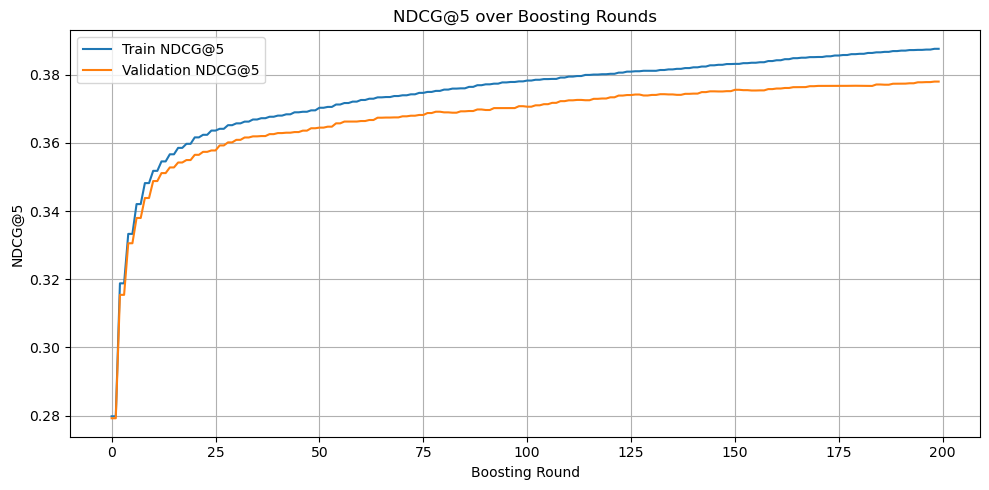

Final NDCG@5 on validation set: 0.37802


In [ ]:
# Plot training and validation NDCG@5 over boosting rounds
evals_result = model.evals_result_

plt.figure(figsize=(10, 5))
plt.plot(evals_result["train"]["ndcg@5"], label="Train NDCG@5")
plt.plot(evals_result["val"]["ndcg@5"], label="Validation NDCG@5")
plt.xlabel("Boosting Round")
plt.ylabel("NDCG@5")
plt.title("NDCG@5 over Boosting Rounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print final validation score
final_val_score = evals_result["val"]["ndcg@5"][-1]
print(f"Final NDCG@5 on validation set: {final_val_score:.5f}")

# converting from test input to list output


In [ ]:
def get_predictions(model:lgb.LGBMRanker)-> pd.DataFrame:
    # Test output
    # LamdaMART predicts real-valued 'RELEVANCE' independent of grouping
    #   given X_test (without search_id) it predicts relevance for each row
    #   each query can then be sorted by this predicted relevance
    TESTDF = pd.read_csv('test_set_VU_DM.csv')
    # add relevant information from date-time 
    TESTDF = preprocess_df(TESTDF, TEST=True)
    
    # Produce relevance predictions for each row
    X_test = TESTDF.drop(columns=['srch_id'])
    predicted_relevance = model.predict(X_test)

    # Add predictions to dataset
    TESTDF['predicted_relevance'] = predicted_relevance

    # Produce ranking predictions for each search ID
    RANKED = TESTDF.sort_values(['srch_id', 'predicted_relevance'], 
                                # from search id 0, ...; within each search id FROM highest relevance)
                                ascending=[True, False]).reset_index(drop=True)

    return RANKED[['srch_id', 'prop_id']] 


if _name_ == '_main_':
    LambdaMART = train_model(plot=True)
    TEST_pred = get_predictions(LambdaMART)
    TEST_pred.to_csv('VU-DM-2025-Group-100.csv', index=False)